<p align="center">
<a href="https://duckietown.com"><img src="../assets/images/dtlogo.png" alt="Duckietown Logo" width="50%"></a>
</p>

# 💻 PID for Lateral Control 

In the previous activities we have built up the tools needed to deploy a PID controller. We have used as control signal the angular speed ($\omega$) and as controlled variable the heading of the Duckiebot ($\theta$).

In this exercise you will use what you have learned so far to write a PID controller to command the angular speed of your Duckiebot, to compensate an initial lateral position offset of $0.2 \text{m}$. 

Your robot will have to rely on its own odometry to estimate its current position.

**Note**: the function(s) used to compute the odometry are provided for you here.

May the duck be with you!

## Implement PID controller for lateral control

Implement the function `OffsetControl` inside the file [pid_controller.py](../packages/solution/pid_controller.py).

The controller you are asked to write performs PID control on the $y$ coordinate (in the world frame) of the Duckiebot. It receives the following inputs:

    v_ref:      linear Duckiebot speed.
    y_ref:      reference heading pose.
    theta_curr: the current estimated heading.
    y_curr:     the current estimated "y" coordinate (offset)
    delta_t:    time interval since last call.

and it will produce the following outputs:

    v:       linear velocity of the Duckiebot
    omega:   angular velocity of the Duckiebot


### Sanity Check

In [1]:
%load_ext autoreload
%autoreload 2

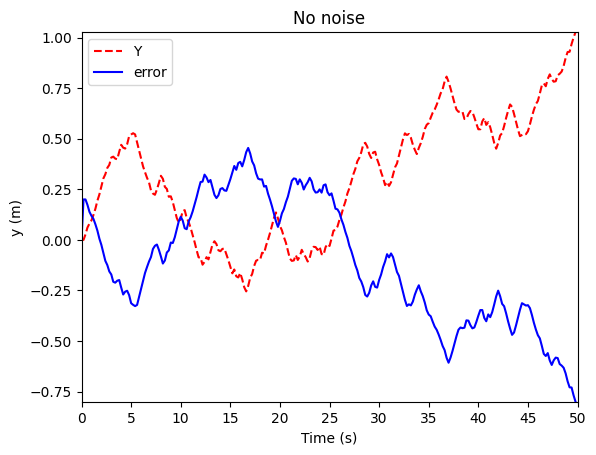

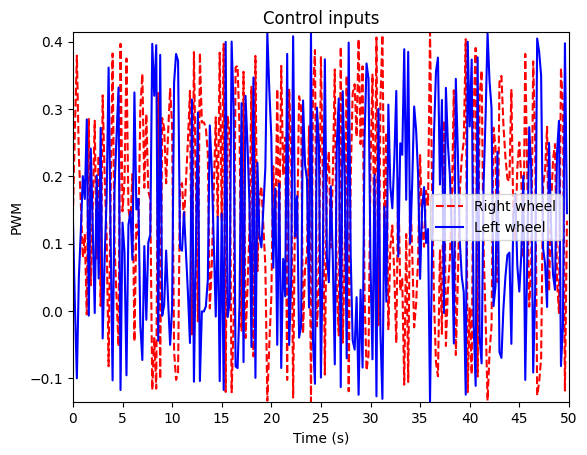

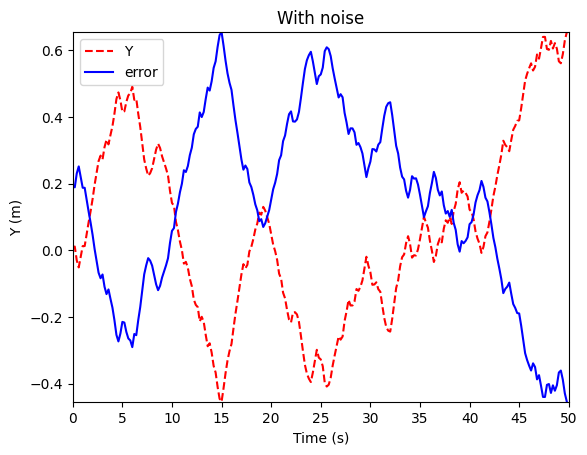

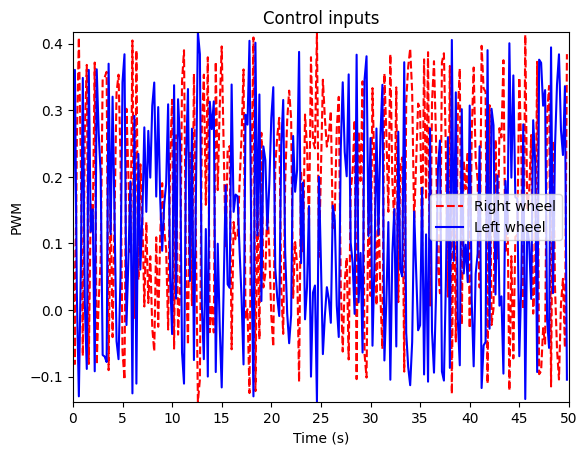

In [2]:
sys.path.append('../packages/tests/')

from unit_test import UnitTestPositionPID

from solution.pid_controller import PIDController

# Write here the values of the kinematics parameters you calculated during the activities.
# This test will give you an idea of the behavior of the controller you wrote above.
# Try to play with the parameters, change R, the baseline all the PID variables,
# What change in the resulting graphs? Why?

# Note: this sanity check is neither a prerequisite for completing the exercise nor an instrument for tuning your controller. 

R = 0.0318
baseline = 0.1
gain = 0.6
trim = 0.0
v_0 = 0.2
y_ref = 0.2

# unit test input R, baseline, v_0, gain, trim, PIDController
unit_test = UnitTestPositionPID(R, baseline, v_0, y_ref, gain, trim, PIDController) 
unit_test.test()


# PID tuning

In order to tune the PID two approaches of increasing fedelity are possible:
1. Kinematic model $\dot{q}=Aq$: only simulating the kinematics of the Duckiebot
2. Dynamics model $F=ma$: simulate the dynamics of the Duckiebot, with forces and inertia.

### Tuning scenario
You will tune the PID in a scenario similar to the one in the first AIDO challenge of this learning experience:

- **Starting pose:** $x_0,y_0,\theta_0=[0 m, 0.2 m, 0°]$
- **Commanded velocity:** $v_0=0.22m/s$
- **Goal**: getting to $y_{ref}=0.0m$

This is equivalent to starting in the wrong lane and try following the centerline of the correct lane.

In [3]:
# Initial conditions of the duckiebot
x0 = 0.0
y0 = 0.2
theta_0 = 0.0 # degrees

initial_pose =  [x0,y0,theta_0]
initial_vel =   [0.0, 0]

# Goal:
y_ref = 0

# Kinematic model
In this part of the notebook you will tune the PID on a kinematic model of the Duckiebot. This is the simplest model of the robot and it will be your first step to get an idea of the values.

In [4]:
import matplotlib.pyplot as plt

from utils.writer import load_gains, update_gains

def plot_xy_from_lists(xs,ys,y_ref):
    # Plot (x,y) position
    ax = plt.subplot(313)
    plt.grid('on')
    plt.plot(xs, ys)

    plt.axhline(y = y_ref, color = 'r', linestyle = '--')

    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)

    # Set grass background
    ax.set_facecolor('g')

    top_line=0.2
    bottom_line=-0.2

    # Draw road
    ax.axhspan(ymin=bottom_line,ymax=top_line,facecolor='k')
    plt.axhline(y=top_line,linestyle='-',color='w') # white
    plt.axhline(y=bottom_line,linestyle='-',color='w')
    plt.axhline(y=0.0,linestyle='--',color='#fefe03')

    ax.set_ylim(bottom=-0.3,top=0.3)

    plt.show()


In [5]:
from simulators import integrate_kinematics
from solution.pid_controller import PIDController

def compute_response(initial_pose, initial_vel = [0,0], y_ref=0,dynamics=integrate_kinematics):
    
    xs, ys, omegas, e_list, angles = dynamics(
        initial_pose,initial_vel,y_ref,controller=PIDController,
        )
        
    plot_xy_from_lists(xs,ys,y_ref)

def tune_gains(kp,kd,ki):
        # write values from sliders to file GAINS.yaml
        update_gains(kp,kd,ki)

        # simulate the controller
        compute_response(initial_pose,y_ref=y_ref,dynamics=integrate_kinematics)

from ipywidgets import interact

interact(tune_gains, kp=5.0,kd=5.0,ki=1.0)

/code/src/Control/packages/simulators/dynamics_sim.py:118: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (delta_phi is not None, "Need to pass a delta_phi function!")
DEBUG:commons:version: 6.2.4 *
DEBUG:typing:version: 6.2.3
DEBUG:duckietown_world:duckietown-world version 6.4.3 path /usr/local/lib/python3.8/dist-packages
DEBUG:geometry:PyGeometry-z6 version 2.1.4 path /usr/local/lib/python3.8/dist-packages
DEBUG:aido_schemas:aido-protocols version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:nodes:version 6.2.17 path /usr/local/lib/python3.8/dist-packages pyparsing 3.1.2


interactive(children=(FloatSlider(value=5.0, description='kp', max=15.0, min=-5.0), FloatSlider(value=5.0, des…

<function __main__.tune_gains(kp, kd, ki)>

# PID Tuning - Dynamic model
For convenience you can simulate here the dynamic behavior of the robot on the x-y plane without having to run the full simulator. This allows you to tweak the gains of the PID and quickly see the effect on the response of the system.

Let's plot the position of the duckiebot on the $xy$ plane:

In [6]:
from simulators import integrate_dynamics
from solution.pid_controller import PIDController

def tune_gains(kp,kd,ki):
        # write values from sliders to file OFFSET_GAINS.yaml
        update_gains(kp,kd,ki)

        # simulate the controller
        compute_response(initial_pose,y_ref=y_ref,dynamics=integrate_dynamics)

interact(tune_gains, kp=5.0,kd=5.0,ki=1.0)

interactive(children=(FloatSlider(value=5.0, description='kp', max=15.0, min=-5.0), FloatSlider(value=5.0, des…

<function __main__.tune_gains(kp, kd, ki)>

# PID Tuning: dynamic model with odometry

Now to get the current pose we use the odometry function you developed. In particular $\hat{y}$ (the estimate of the current $y$ position) is fed to the PID controller and the `dynamics` function now also gets as argument the two functions you developed in the odometry activity (`delta_phi` and `pose_estimation`).

In [7]:
from encoder_pose.include.odometry import  delta_phi, estimate_pose

# We redefine `compute_response` to use the odometry functions as well

def compute_response(initial_pose, initial_vel = [0,0], y_ref=0,dynamics=integrate_kinematics):
    
    xs, ys, omegas, e_list, angles = dynamics(
        initial_pose,initial_vel,y_ref,controller=PIDController,odometry_function=estimate_pose,delta_phi=delta_phi
        )
        
    plot_xy_from_lists(xs,ys,y_ref)

def tune_gains(kp,kd,ki):
        # write values from sliders to file GAINS.yaml
        update_gains(kp,kd,ki)

        # simulate the controller
        compute_response(initial_pose,y_ref=y_ref,dynamics=integrate_dynamics)

interact(tune_gains, kp=5.0,kd=5.0,ki=1.0)

interactive(children=(FloatSlider(value=5.0, description='kp', max=15.0, min=-5.0), FloatSlider(value=5.0, des…

<function __main__.tune_gains(kp, kd, ki)>

You see that there's a difference in the behavior of the robot compared to the dynamics simulator _without odometry_.

*   Can you explain what is it?
*   What do you think might be the cause of this difference?
*   How could you check if your hypothesis is correct?

### 💻 Test the controller in simulation

Follow [the instructions in the book](TODO) to create a virtual robot, start the Duckiematrix, build and run your code, and finally run the noVNC browser. 

Open VNC on you browser and click on the `PID_Heading` icon on your desktop. You will see the following open (it might take ~30second or more, depending on the specifications of your computer):

    - A preconfigured RVIZ: to visualize performance
    - an LX terminal: `Ctrl-C` here to return to VNC. 
    - an interaction window with fields `ref` and and `v_0`, and buttons `Send Commands` and `Stop`. 


In the RVIZ terminal you should see what the robot sees. Nothing should be moving. You will see some debugging data in the terminal running on your computer where you launched the activity from. 

To initialize the testing of your controller, you will have to insert values for `ref` (in **meters**) and `v_0` (between -1 and 1) and press on `Send Commands`. The controller you designed above will then start computing the $\omega$ and the robot will start driving. 

Good example values for this activity are $ref = 0.2$ and $v_0 = 0.2$, but you can play with these parameters at runtime and see how your PID controller performs. If you run too far off the road, you can use the joystick to manually drive your robot back to the road. 



<figure>
  <div style="text-align:center;">
  <img src="../assets/images/pid-control/pid-lateral-sim-good.png" alt="pid-lateral-sim-1" style="width: 300px;"/>
  <p>Simulation, lateral PID control. 

$$v_{0} = 0.2, y_{ref} = [0.2, -0.1]$$
</p>
  </div>
</figure>

To test different solutions, change the `OffsetControl` function you wrote, save this file (`Ctrl-S`) and re-build and re-run  


### 🚙 Test the controller on your Duckiebot

You can follow a similar procedure as above (and outlined [in the instructions](TODO)) to test your code on your real Duckiebot.

**Note**: we suggest to start at very slow speeds with the physical Duckiebot, and get a hang of the interface first. Going wasted in simulation is just a matter of re-setting the instance. Having the Duckiebot go wasted in the physical world might be significantly more time consuming!


<figure>
  <div style="text-align:center;">
  <img src="../assets/images/pid-control/pid-lateral-real-good.png" alt="pid-lateral-real-1" style="width: 300px;"/>
  <p>Duckiebot, lateral PID control. 
  
  $$v_{0} = 0.2, y_{ref} = [0.2, -0.2, 0.2]$$
  </p>
  </div>
</figure>

As before, change the `OffsetControl` funtion you wrote, save this file (`Ctrl-S`) and re-build and re-run. 


Congratulations, you have completed the control exercise! 